# **IRWA Final Project**

Authors: Carla Núñez u214970  /  Julia Pérez u214026  /  Jan Prats u213927

GitHub URL: https://github.com/Januto30/SearchEngine-IRWA_2025

TAG:


## **Part 0 -  Text Processing and Exploratory Data Analysis**

### 1.1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#jan
docs_path_json = '/content/drive/MyDrive/Web/IRWA_project_part_2/data/fashion_products_dataset.json'

#julia
#docs_path_json = '/content/drive/MyDrive/4t/Web/IRWA_project_part_2/data/fashion_products_dataset.json'

#carla
#docs_path_json = '/content/drive/MyDrive/data/fashion_products_dataset.json'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Standard library imports
import json
import math
import re
import string
import datetime
from array import array
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from wordcloud import WordCloud

#NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

#Download NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
with open(docs_path_json, 'r', encoding='utf-8') as f:
    json_data_products = json.load(f)

# Convert JSON list of dicts into DataFrame
df_products = pd.DataFrame(json_data_products)

### 1.2.Preprocessing function

In [ ]:
def build_terms(line):
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words("english"))      #Stop words

    line= line.lower()                                #Transform in lowercase
    line= re.sub(r'[^a-z0-9\s]', ' ', line)           #Remove non‑alphanumeric characters (removing punctuation marks, keep spaces)
    line= re.sub(r'\s+', ' ', line).strip()           #Collapse multiple spaces into a single space
    line= line.split()                                #Tokenize the text to get a list of terms
    line=[x for x in line if x not in stop_words]     #Eliminate the stopwords
    line=[stemmer.stem(word) for word in line]        #Perform stemming (teacher --> teach)

    return line

#Apply preprocessing to title and description
df_products['title_clean'] = df_products['title'].apply(build_terms)
df_products['description_clean'] = df_products['description'].apply(build_terms)

#Combine product_details into a single text field
def combine_product_details(details_list):
    if isinstance(details_list, list):
        return " ".join([str(list(d.values())[0]) for d in details_list])
    return ""

df_products['product_details_text'] = df_products['product_details'].apply(combine_product_details)

### 1.3.Preprocessing for example

In [ ]:
preprocessed_products = []

for prod in json_data_products:
    #Get the text fields (if missing, use empty string)
    title_raw = prod.get('title', '')
    descr_raw = prod.get('description', '')

    #Apply preprocessing pipeline
    title_tokens = build_terms(title_raw)
    descr_tokens = build_terms(descr_raw)

    #Keep all original fields along with the processed tokens
    prod_processed = {
        **prod,  # conservar tots els camps originals
        'title_tokens': title_tokens,
        'description_tokens': descr_tokens
    }
    preprocessed_products.append(prod_processed)

#Show the first product before and after preprocessing
first_raw = json_data_products[0]
first_proc = preprocessed_products[0]

print("=== Original Product ===")
print(f"Title      : {first_raw.get('title', 'N/A')}")
print(f"Description: {first_raw.get('description', 'N/A')}")

print("\n=== After Preprocessing ===")
print(f"Title Tokens      : {first_proc['title_tokens']}")
print(f"Description Tokens: {first_proc['description_tokens']}")

=== Original Product ===
Title      : Solid Women Multicolor Track Pants
Description: Yorker trackpants made from 100% rich combed cotton giving it a rich look.Designed for Comfort,Skin friendly fabric,itch-free waistband & great for all year round use Proudly made in India

=== After Preprocessing ===
Title Tokens      : ['solid', 'women', 'multicolor', 'track', 'pant']
Description Tokens: ['yorker', 'trackpant', 'made', '100', 'rich', 'comb', 'cotton', 'give', 'rich', 'look', 'design', 'comfort', 'skin', 'friendli', 'fabric', 'itch', 'free', 'waistband', 'great', 'year', 'round', 'use', 'proudli', 'made', 'india']


### 1.4.Exploratory data analysis

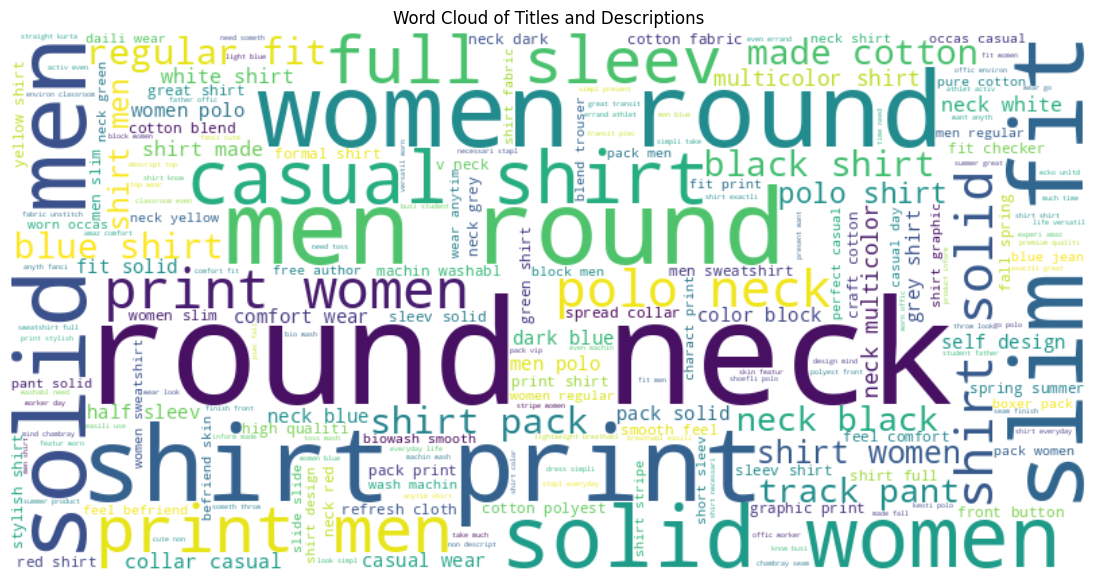

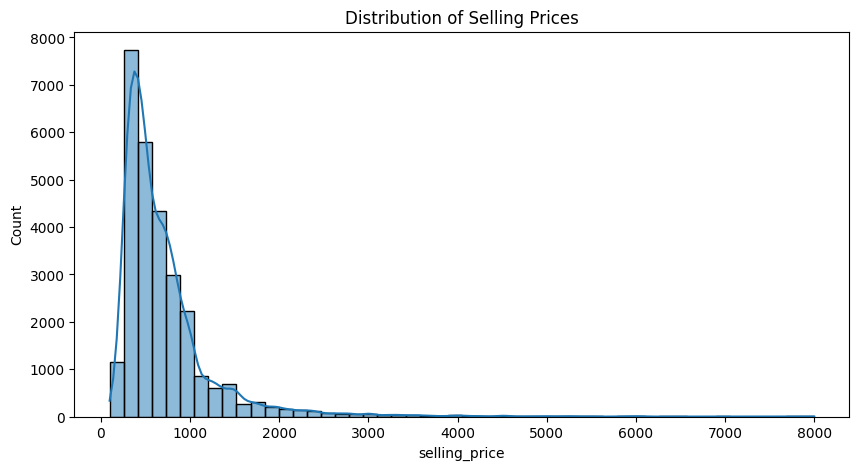

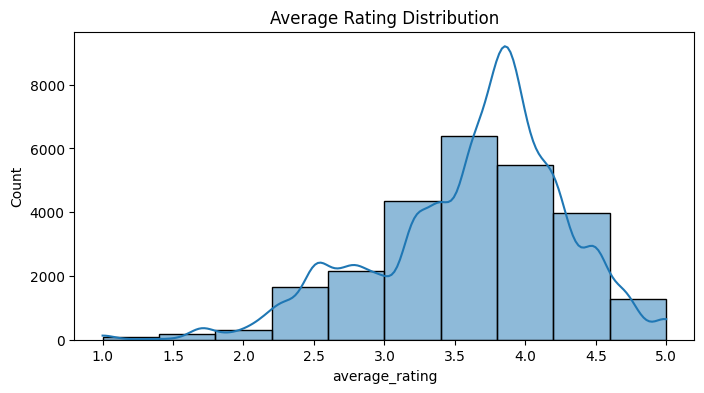

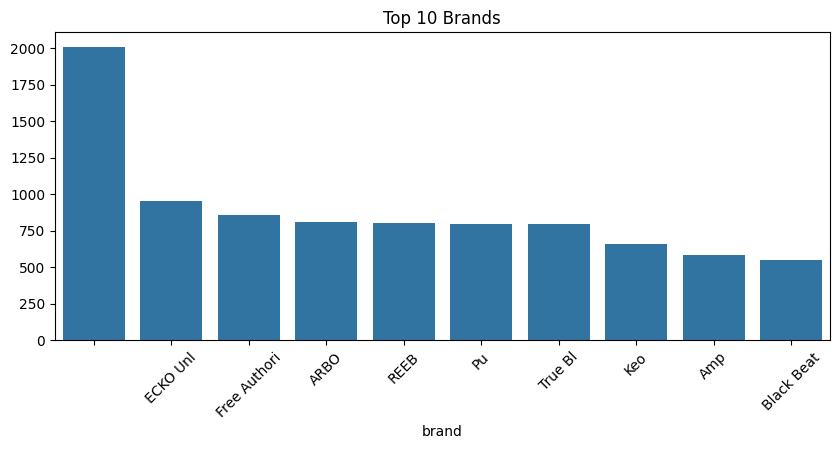

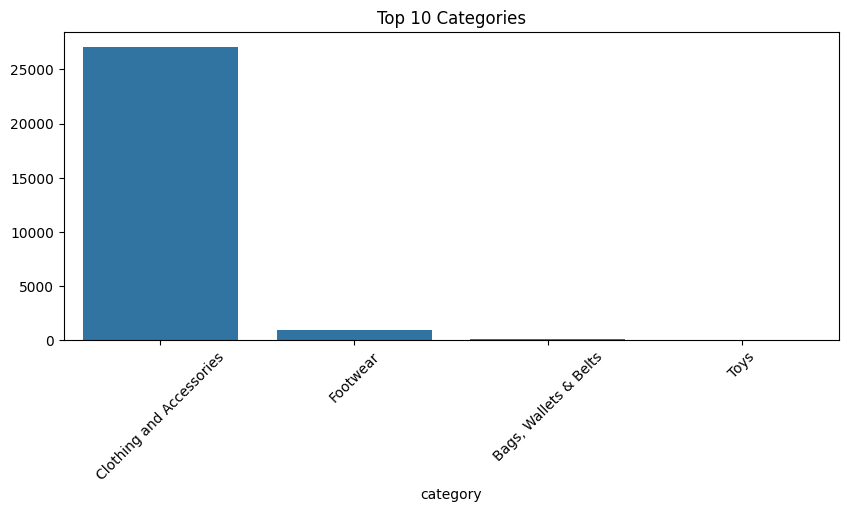

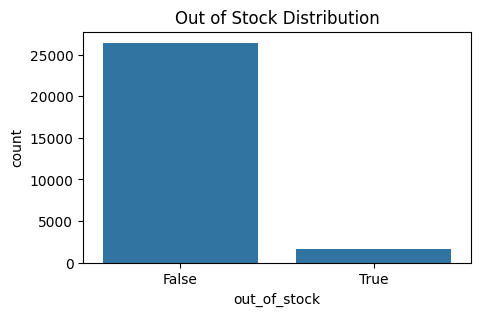

In [ ]:
#Word Cloud
text_combined = " ".join([" ".join(x) for x in df_products['title_clean']] +
                         [" ".join(x) for x in df_products['description_clean']])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Titles and Descriptions")
plt.show()

#Distribution of prices
df_products['selling_price'] = pd.to_numeric(df_products['selling_price'].str.replace(',', ''), errors='coerce')
df_products['actual_price'] = pd.to_numeric(df_products['actual_price'].str.replace(',', ''), errors='coerce')

plt.figure(figsize=(10,5))
sns.histplot(df_products['selling_price'].dropna(), bins=50, kde=True)
plt.title("Distribution of Selling Prices")
plt.show()

#Average rating distribution
df_products['average_rating'] = pd.to_numeric(df_products['average_rating'], errors='coerce')

plt.figure(figsize=(8,4))
sns.histplot(df_products['average_rating'].dropna(), bins=10, kde=True)
plt.title("Average Rating Distribution")
plt.show()

#Top brands and categories
top_brands = df_products['brand'].value_counts().head(10)
top_categories = df_products['category'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top 10 Brands")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Top 10 Categories")
plt.xticks(rotation=45)
plt.show()

#Out of stock distribution
plt.figure(figsize=(5,3))
sns.countplot(x='out_of_stock', data=df_products)
plt.title("Out of Stock Distribution")
plt.show()

preprocessed_cols = ['pid', 'title_clean', 'description_clean', 'brand', 'category',
                     'sub_category', 'product_details_text', 'seller', 'out_of_stock',
                     'selling_price', 'discount', 'actual_price', 'average_rating', 'url']

df_products[preprocessed_cols].to_csv("preprocessed_fashion_products.csv", index=False)

## **Part 1 -  Indexing**

### 2.1.Build inverted index and TF-IDF data structures


In [ ]:
def create_index_tfidf_from_products(df_products):
    """
    Create inverted index, tf, df, and idf structures for product dataset.
    """
    index = defaultdict(list)
    tf = defaultdict(list)  # term frequencies of terms in documents
    df_counts = defaultdict(int)  # document frequencies of terms
    idf = defaultdict(float)
    doc_titles = {}

    # Combine all preprocessed text fields for indexing
    documents = {}
    for idx, row in df_products.iterrows():
        details = row['product_details_text'] if isinstance(row['product_details_text'], str) else ""
        combined_text = " ".join([
            " ".join(row['title_clean']),
            " ".join(row['description_clean']),
            details
        ])
        documents[idx] = combined_text
        # si el DataFrame no té la columna 'title', usem title_clean
        doc_titles[idx] = row['title'] if 'title' in row else " ".join(row['title_clean'])

    num_documents = len(documents)

    # build index
    for doc_id, text in documents.items():
        terms = build_terms(text)
        current_page_index = {}

        for pos, term in enumerate(terms):
            if term in current_page_index:
                current_page_index[term][1].append(pos)
            else:
                current_page_index[term] = [doc_id, array('I', [pos])]

        # Compute normalization factor for TF
        norm = math.sqrt(sum(len(posting[1]) ** 2 for posting in current_page_index.values()))

        # Compute TF and DF
        for term, posting in current_page_index.items():
            tf[term].append(round(len(posting[1]) / norm, 4))
            df_counts[term] += 1
            index[term].append(posting)

    # compute IDF
    for term, df_val in df_counts.items():
        idf[term] = round(np.log((1 + num_documents) / (1 + df_val)), 4)

    return index, tf, df_counts, idf, doc_titles


### 2.2.Provide ranking-based results (Conjunctive AND queries)

In [ ]:
# Afegim un diccionari que relacioni cada doc_id amb el seu pid
pid_map = df_products['pid'].to_dict()  # {row_index: pid}

def search_query(query, index, tf, idf, doc_titles, pid_map):
    """
    Execute a conjunctive AND query using TF-IDF ranking.
    Returns list of (pid, score)
    """
    query = build_terms(query)
    if not query:
        return []

    # Get list of document IDs per term
    doc_sets = []
    for term in query:
        if term in index:
            doc_ids = [posting[0] for posting in index[term]]
            doc_sets.append(set(doc_ids))
        else:
            return []

    # Intersect (AND) all document sets
    matching_docs = set.intersection(*doc_sets)
    if not matching_docs:
        return []

    # Compute TF-IDF ranking
    scores = defaultdict(float)
    for term in query:
        if term in index:
            for i, posting in enumerate(index[term]):
                doc_id = posting[0]
                if doc_id in matching_docs:
                    scores[doc_id] += tf[term][i] * idf[term]

    # Rank in descending order
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [(pid_map[doc_id], score) for doc_id, score in ranked]  # return pid, not title


### 2.3.Propose test queries and show ranked results

In [ ]:
test_queries = [
    "hardware components",
    "round neck blue shirt",
    "casual shirt men",
    "women slim fit",
    "polo ice cream"
]

In [ ]:
# Build the index
index, tf, df_counts, idf, doc_titles = create_index_tfidf_from_products(df_products)

for q in test_queries:
    results = search_query(q, index, tf, idf, doc_titles, pid_map)
    print(f"\nQuery: '{q}'")

    if not results:  # check if list is empty
        print("No matching products found in the dataset for this query.")
        continue

    for pid, score in results[:10]:
        title = df_products.loc[df_products['pid'] == pid, 'title'].values[0]
        print(f"  {pid} | {title[:55]}...  (score={score:.4f})")



Query: 'hardware components'
No matching products found in the dataset for this query.

Query: 'round neck blue shirt'
  TSHFWSAQGM4NDRZV | Solid Men Round Neck Blue T-Shirt...  (score=1.4428)
  TSHFVW7FXGAPEXFE | Typography Men Round Neck Blue T-Shirt...  (score=1.4157)
  TSHFYRYBHWBHF4WU | Solid Women Round Neck Blue T-Shirt  (Pack of 4)...  (score=1.4057)
  TSHFVTWHZKS6MWAE | Typography Women Round Neck Blue T-Shirt...  (score=1.3970)
  TSHFKWPTYYWSTSZJ | Printed Women Round Neck Dark Blue, Blue T-Shirt  (Pack...  (score=1.3829)
  TSHFEY8VRGCMRSGG | Typography Women Round Neck Blue T-Shirt...  (score=1.3777)
  TSHFVK5QPHBCKXU2 | Textured Men Round Neck Blue T-Shirt...  (score=1.3726)
  TSHFHBQN5Y8EMDWZ | Solid Women Round Neck Blue T-Shirt...  (score=1.3711)
  TSHFHHQFEQT56GZP | Color Block Men Round Neck Blue T-Shirt...  (score=1.3680)
  TSHFEY8WPK7F3TG5 | Color Block Men Round Neck Blue T-Shirt...  (score=1.3642)

Query: 'casual shirt men'
  SHTFACSAS6WTFZ5G | Men Slim Fit Solid 

## **Part 2 -  Evaluation**

### 1. Implement evaluation metrics to assess the effectiveness of the retrieval solutions

In [ ]:
# P@K
def precision_at_k(relevance_list, k):
    relevance = np.array(relevance_list)[:k]
    return np.mean(relevance) if len(relevance) > 0 else 0.0

# R@K
def recall_at_k(relevance_list, total_relevant, k):
    relevance = np.array(relevance_list)[:k]
    return np.sum(relevance) / total_relevant if total_relevant > 0 else 0.0

# avg P@K
def average_precision_at_k(relevance_list, k):
    relevance = np.array(relevance_list)[:k]
    precisions = [precision_at_k(relevance_list, i + 1)
                  for i in range(len(relevance)) if relevance[i]]
    return np.mean(precisions) if len(precisions) > 0 else 0.0

# F1@Score
def f1_at_k(precision, recall):
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# MAP
def mean_average_precision(all_relevance_lists, k):
    ap_scores = [average_precision_at_k(rel, k) for rel in all_relevance_lists]
    return np.mean(ap_scores)

# RR
def reciprocal_rank(relevance_list):
    for i, rel in enumerate(relevance_list):
        if rel == 1:
            return 1 / (i + 1)
    return 0.0

# MRR
def mean_reciprocal_rank(all_relevance_lists):
    return np.mean([reciprocal_rank(rel) for rel in all_relevance_lists])

# NDCG
def ndcg_at_k(relevance_list, k):
    rel = np.array(relevance_list)[:k]
    dcg = np.sum(rel / np.log2(np.arange(2, len(rel) + 2)))
    ideal_rel = np.sort(rel)[::-1]
    idcg = np.sum(ideal_rel / np.log2(np.arange(2, len(ideal_rel) + 2)))
    return dcg / idcg if idcg > 0 else 0.0


# function to evaluate a query
def evaluate_query(query_id, results, labels_df, k):
    query_labels = labels_df[labels_df['query_id'] == query_id]
    relevance = [
        int(query_labels[query_labels['pid'] == pid]['labels'].values[0])
        if pid in list(query_labels['pid']) else 0
        for pid, _ in results[:k]
    ]
    total_relevant = query_labels['labels'].sum()

    P = precision_at_k(relevance, k)
    R = recall_at_k(relevance, total_relevant, k)
    AP = average_precision_at_k(relevance, k)
    F1 = f1_at_k(P, R)
    RR = reciprocal_rank(relevance)
    NDCG = ndcg_at_k(relevance, k)

    # Construir diccionario de métricas
    metrics = {
        'P@K': round(P, 3),
        'R@K': round(R, 3),
        'AP@K': round(AP, 3),
        'F1@K': round(F1, 3),
        'RR': round(RR, 3),
        'NDCG': round(NDCG, 3)
    }

    # Imprimir con formato bonito
    print(f"\nQuery {query_id} metrics:")
    print(tabulate(metrics.items(), headers=["Metric", "Value"], tablefmt="grid"))

    return metrics

### 2. Apply the evaluation metrics implemented to the search results and relevance judgments.

In [ ]:
labels_path = '/content/drive/MyDrive/Web/IRWA_project_part_2/data/validation_labels.csv'
#carla
#labels_path = '/content/drive/MyDrive/data/validation_labels.csv'

labels_df = pd.read_csv(labels_path)

q1_text = "women full sleeve sweatshirt cotton"
q2_text = "men slim jeans blue"

results_q1 = search_query(q1_text, index, tf, idf, doc_titles, pid_map)
results_q2 = search_query(q2_text, index, tf, idf, doc_titles, pid_map)

eval_q1 = evaluate_query(1, results_q1, labels_df, k=10)
eval_q2 = evaluate_query(2, results_q2, labels_df, k=10)

# Overall metrics
all_relevance_lists = []
for qid, results in zip([1, 2], [results_q1, results_q2]):
    query_labels = labels_df[labels_df['query_id'] == qid]
    rel_list = [
        int(query_labels[query_labels['pid'] == pid]['labels'].values[0])
        if pid in list(query_labels['pid']) else 0
        for pid, _ in results[:10]
    ]
    all_relevance_lists.append(rel_list)

MAP_score = mean_average_precision(all_relevance_lists, k=10)
MRR_score = mean_reciprocal_rank(all_relevance_lists)

print(f"\nOverall MAP: {MAP_score:.3f}")
print(f"Overall MRR: {MRR_score:.3f}")



Query 1 metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |       0 |
+----------+---------+
| R@K      |       0 |
+----------+---------+
| AP@K     |       0 |
+----------+---------+
| F1@K     |       0 |
+----------+---------+
| RR       |       0 |
+----------+---------+
| NDCG     |       0 |
+----------+---------+

Query 2 metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |   0.1   |
+----------+---------+
| R@K      |   0.1   |
+----------+---------+
| AP@K     |   0.5   |
+----------+---------+
| F1@K     |   0.1   |
+----------+---------+
| RR       |   0.5   |
+----------+---------+
| NDCG     |   0.631 |
+----------+---------+

Overall MAP: 0.250
Overall MRR: 0.250


### 3.  establishing the ground truth for each document and query

In [ ]:
1# test_queries defined in Section 2.3
"""
test_queries = [
    "hardware components",
    "round neck blue shirt",
    "casual shirt men",
    "women slim fit",
    "polo ice cream"
]
"""
query_ids = [1, 2, 3, 4, 5]

# Create inverse mapping PID → document index (to fetch titles correctly)
pid_to_docid = {v: k for k, v in pid_map.items()}

# Dictionary to store results
results_dict = {}

# Dictionary to store real relevance
ground_truth_custom = {}

# Display top search results per query in test_queries
print("=== Top search results per query ===")

for qid, query in zip(query_ids, test_queries):
  results = search_query(query, index, tf, idf, doc_titles, pid_map)  # return (pid_map[doc_id], score) for doc_id, score in ranked
  results_dict[qid] = results

  print(f"\nQuery {qid}: '{query}'")

  if not results:  #list of results empty
      print("No matching products found in the dataset for this query.\n")
      ground_truth_custom[qid] = {}
      continue

  rows = []
  for i, (pid, score) in enumerate(results[:5]):
      title = doc_titles.get(pid_to_docid.get(pid, -1), "Unknown Title")
      short_title = title[:70] + ("..." if len(title) > 70 else "")
      rows.append([i + 1, pid, short_title, f"{score:.4f}"])

  print(tabulate(rows, headers=["Rank", "Product ID", "Title", "Score"], tablefmt="grid"))

  # assign Binary Relevance Judgments
  # Dictionary to save relevant documents for the expert
  pid_relevance = {}
  for i, (pid, score) in enumerate(results[:5]):
      while True:
        # 1 = relevant, 0 = not relevant (manually)
        user_input = input(f"Is Document ranked {i+1} relevant to query '{query}'? (1=Yes, 0=No): ").strip()
        if user_input in ["0", "1"]:
          relevance = int(user_input)
          pid_relevance[pid] = relevance
          break  # exit the loop once valid input is given
        else:
          print("Invalid input! Please enter 1 for relevant or 0 for not relevant.")


  ground_truth_custom[qid] = pid_relevance


print("\n=== Evaluation metrics ===")

query_evaluations = {}
all_relevance_lists = []

for qid, qtext in zip(query_ids, test_queries):
    results = results_dict[qid]

    if not results:
        print(f"\nQuery {qid} ('{qtext}') has no retrieved documents.")
        continue

    relevant_pids = [pid for pid, label in ground_truth_custom[qid].items() if label == 1]
    relevance_list = [1 if pid in relevant_pids else 0 for pid, _ in results[:5]]
    all_relevance_lists.append(relevance_list)

    total_relevant = sum(relevance_list)
    P = precision_at_k(relevance_list, k=5)
    R = recall_at_k(relevance_list, total_relevant, k=5)
    AP = average_precision_at_k(relevance_list, k=5)
    F1 = f1_at_k(P, R)
    RR = reciprocal_rank(relevance_list)
    NDCG = ndcg_at_k(relevance_list, k=5)

    metrics = {
        'P@K': round(P, 3),
        'R@K': round(R, 3),
        'AP@K': round(AP, 3),
        'F1@K': round(F1, 3),
        'RR': round(RR, 3),
        'NDCG': round(NDCG, 3)
    }

    query_evaluations[qid] = metrics
    print(f"\nQuery {qid} ('{qtext}') metrics:")
    print(tabulate(metrics.items(), headers=["Metric", "Value"], tablefmt="grid"))

# Overall Evaluation

MAP_custom = mean_average_precision(all_relevance_lists, k=5)
MRR_custom = mean_reciprocal_rank(all_relevance_lists)

print("\nOverall evaluation results:")
print(f"Mean Average Precision (MAP):  {MAP_custom:.3f}")
print(f"Mean Reciprocal Rank (MRR):    {MRR_custom:.3f}")


=== Top search results per query ===

Query 1: 'hardware components'
No matching products found in the dataset for this query.


Query 2: 'round neck blue shirt'
+--------+------------------+---------------------------------------------------------------+---------+
|   Rank | Product ID       | Title                                                         |   Score |
+========+==================+===============================================================+=========+
|      1 | TSHFWSAQGM4NDRZV | Solid Men Round Neck Blue T-Shirt                             |  1.4428 |
+--------+------------------+---------------------------------------------------------------+---------+
|      2 | TSHFVW7FXGAPEXFE | Typography Men Round Neck Blue T-Shirt                        |  1.4157 |
+--------+------------------+---------------------------------------------------------------+---------+
|      3 | TSHFYRYBHWBHF4WU | Solid Women Round Neck Blue T-Shirt  (Pack of 4)              |  1.4057 |
+-----

In [ ]:
def evaluate_results(ground_truth, results_dict, test_queries, query_ids):

    print("\n=== Evaluation metrics ===")

    query_evaluations = {}
    all_relevance_lists = []

    for qid, qtext in zip(query_ids, test_queries):
        results = results_dict.get(qid, [])

        if not results:
            print(f"\nQuery {qid} ('{qtext}') has no retrieved documents.")
            continue

        relevant_pids = [pid for pid, label in ground_truth[qid].items() if label == 1]
        relevance_list = [1 if pid in relevant_pids else 0 for pid, _ in results[:5]]
        all_relevance_lists.append(relevance_list)

        total_relevant = sum(relevance_list)
        P = precision_at_k(relevance_list, k=5)
        R = recall_at_k(relevance_list, total_relevant, k=5)
        AP = average_precision_at_k(relevance_list, k=5)
        F1 = f1_at_k(P, R)
        RR = reciprocal_rank(relevance_list)
        NDCG = ndcg_at_k(relevance_list, k=5)

        metrics = {
            'P@K': round(P, 3),
            'R@K': round(R, 3),
            'AP@K': round(AP, 3),
            'F1@K': round(F1, 3),
            'RR': round(RR, 3),
            'NDCG': round(NDCG, 3)
        }

        query_evaluations[qid] = metrics

        print(f"\nQuery {qid} ('{qtext}') metrics:")
        print(tabulate(metrics.items(), headers=["Metric", "Value"], tablefmt="grid"))

    # Overall Evaluation
    MAP_custom = mean_average_precision(all_relevance_lists, k=5)
    MRR_custom = mean_reciprocal_rank(all_relevance_lists)

    print("\nOverall evaluation results:")
    print(f"Mean Average Precision (MAP):  {MAP_custom:.3f}")
    print(f"Mean Reciprocal Rank (MRR):    {MRR_custom:.3f}")

    return query_evaluations, MAP_custom, MRR_custom


In [ ]:
query_evaluations, MAP_custom, MRR_custom = evaluate_results(
    ground_truth_custom, results_dict, test_queries, query_ids
)


=== Evaluation metrics ===

Query 1 ('hardware components') has no retrieved documents.

Query 2 ('round neck blue shirt') metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |    0.6  |
+----------+---------+
| R@K      |    1    |
+----------+---------+
| AP@K     |    1    |
+----------+---------+
| F1@K     |    0.75 |
+----------+---------+
| RR       |    1    |
+----------+---------+
| NDCG     |    1    |
+----------+---------+

Query 3 ('casual shirt men') metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |   0.4   |
+----------+---------+
| R@K      |   1     |
+----------+---------+
| AP@K     |   0.833 |
+----------+---------+
| F1@K     |   0.571 |
+----------+---------+
| RR       |   1     |
+----------+---------+
| NDCG     |   0.92  |
+----------+---------+

Query 4 ('women slim fit') metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |       1 |
+--------